# Layer-by-layer exploration

Boilerplate only: load the model, load the trained weights, load one sample image.
Everything after "Your exploration starts here" is for you to write.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from models import load_model

In [2]:
# Load the Detector architecture and the trained HW3 weights (detector.th)
model = load_model("detector", with_weights=True)
model.eval()
print(model)

Detector(
  (down1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
  )
  (down2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
  )
  (down3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, t

In [3]:
# Load one sample image and turn it into the (1, 3, H, W) float tensor the model expects
image_path = "drive_data/val/hacienda_05/00000_im.jpg"

image = Image.open(image_path)
image_np = np.array(image) / 255.0  # (H, W, 3), vals in [0, 1]

x = torch.from_numpy(image_np).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
print(x.shape, x.min().item(), x.max().item())

torch.Size([1, 3, 96, 128]) 0.0 1.0


(np.float64(-0.5), np.float64(127.5), np.float64(95.5), np.float64(-0.5))

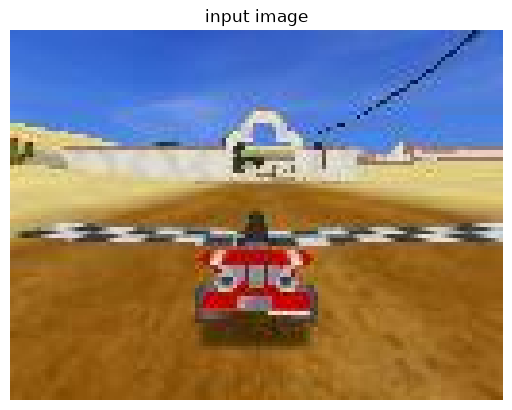

In [4]:
plt.imshow(image_np)
plt.title("input image")
plt.axis("off")

---
## Your exploration starts here

`model`, `x` (input tensor), and `image_np` (for display) are ready.

Try: run `x` through `model.down1` with `torch.no_grad()`, check the output shape, then visualize a few channels with `plt.imshow`.

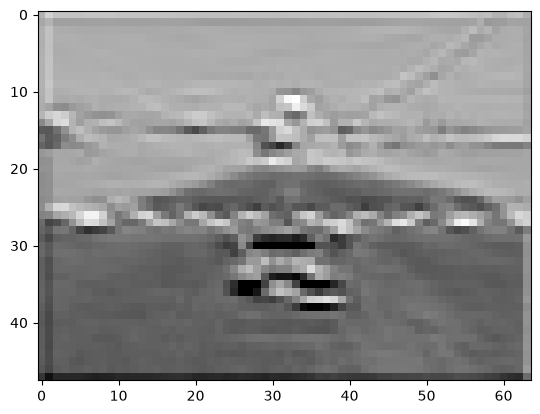

In [5]:
feature1 = model.down1(x)
plt.imshow(feature1.detach().numpy()[0, 6], cmap="gray")

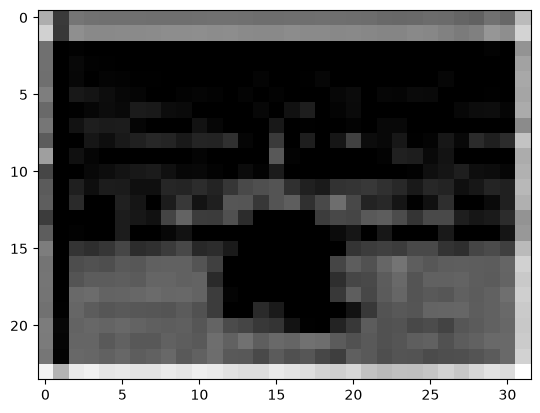

In [6]:
feature2 = model.down2(feature1)
plt.imshow(feature2.detach().numpy()[0, 3], cmap="gray")

In [7]:
feature1.shape

torch.Size([1, 16, 48, 64])

In [8]:
feature2.shape

torch.Size([1, 32, 24, 32])

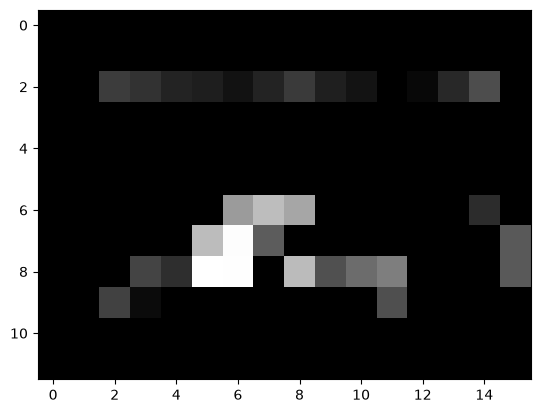

In [9]:
feature3 = model.down3(feature2)
plt.imshow(feature3.detach().numpy()[0, 30], cmap="gray")

(np.float64(-0.5), np.float64(127.5), np.float64(95.5), np.float64(-0.5))

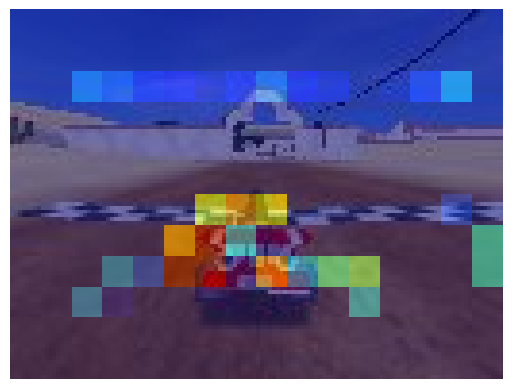

In [10]:
channel = feature3[0, 30].detach().numpy()
resized = np.kron(channel, np.ones((8, 8)))  # upsample by 8x using nearest neighbor

plt.imshow(image_np)
plt.imshow(resized, cmap="jet", alpha=0.5)
plt.axis("off")

In [11]:
seg_feature = model.seg_up1(feature3)
seg_feature = model.relu(seg_feature + feature2)   # add feature2 back in (skip connection)
seg_feature = model.seg_refine1(seg_feature)

seg_feature = model.seg_up2(seg_feature)
seg_feature = model.relu(seg_feature + feature1)   # add feature1 back in
seg_feature = model.seg_refine2(seg_feature)

logits = model.seg_output(seg_feature)
print(logits.shape)  # should be (1, 3, 96, 128) — restored to original resolution


torch.Size([1, 3, 96, 128])


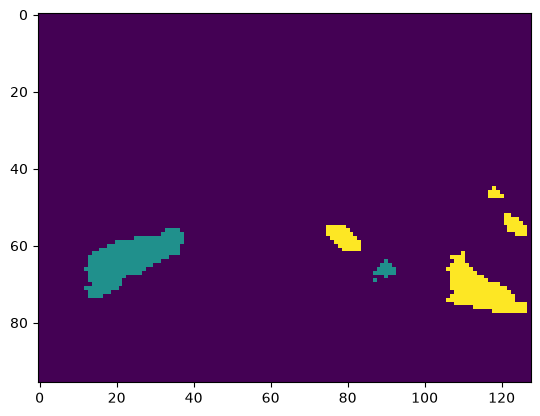

In [12]:
pred = logits.argmax(dim=1)[0]          # (96, 128), class label per pixel
plt.imshow(pred.detach().numpy())


---
## Overlay the segmentation result on the original image

`pred` is already the same 96x128 size as the original, so no need for `np.kron` upsampling — it can be overlaid directly.

(np.float64(-0.5), np.float64(127.5), np.float64(95.5), np.float64(-0.5))

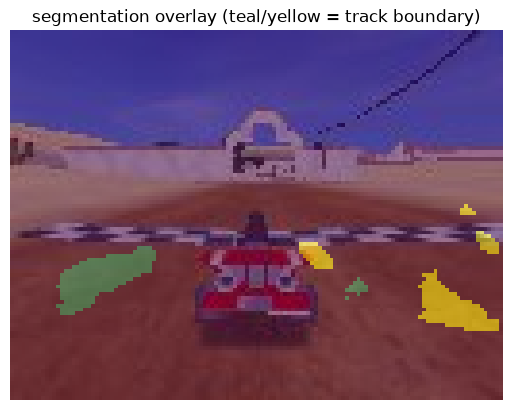

In [13]:
plt.imshow(image_np)
plt.imshow(pred.detach().numpy(), cmap="viridis", alpha=0.5)
plt.title("segmentation overlay (teal/yellow = track boundary)")
plt.axis("off")

---
## Depth head

Same pattern as segmentation — starting from `feature3`, adding `feature2` and `feature1` back in via skip connections to restore the original resolution. The difference: instead of a class, the final output is a single number per pixel (distance), squashed into 0~1 with `sigmoid`.

In [ ]:
depth_feature = model.depth_up1(feature3)
depth_feature = model.relu(depth_feature + feature2)   # skip connection
depth_feature = model.depth_refine1(depth_feature)

depth_feature = model.depth_up2(depth_feature)
depth_feature = model.relu(depth_feature + feature1)   # skip connection
depth_feature = model.depth_refine2(depth_feature)

raw_depth = model.depth_output(depth_feature)
depth = torch.sigmoid(raw_depth).squeeze(dim=1)[0]       # (96, 128), 0~1
print(depth.shape, depth.min().item(), depth.max().item())

torch.Size([96, 128]) 0.5915406942367554 0.9991037249565125


(np.float64(-0.5), np.float64(127.5), np.float64(95.5), np.float64(-0.5))

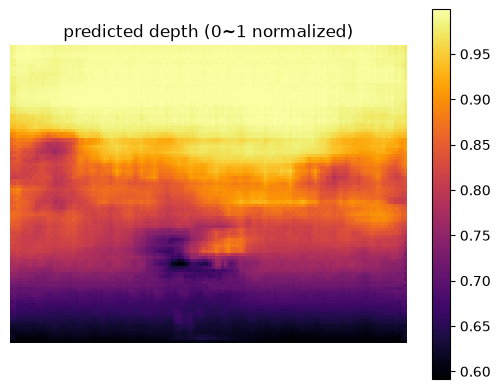

In [ ]:
plt.imshow(depth.detach().numpy(), cmap="inferno")
plt.title("predicted depth (0~1 normalized)")
plt.colorbar()
plt.axis("off")

---
## All together — input / segmentation / depth

This is the model's full forward pass: one image → encoder (down1~3) → decoder that splits into two (seg / depth). The 3 panels below are the final result of everything explored today.

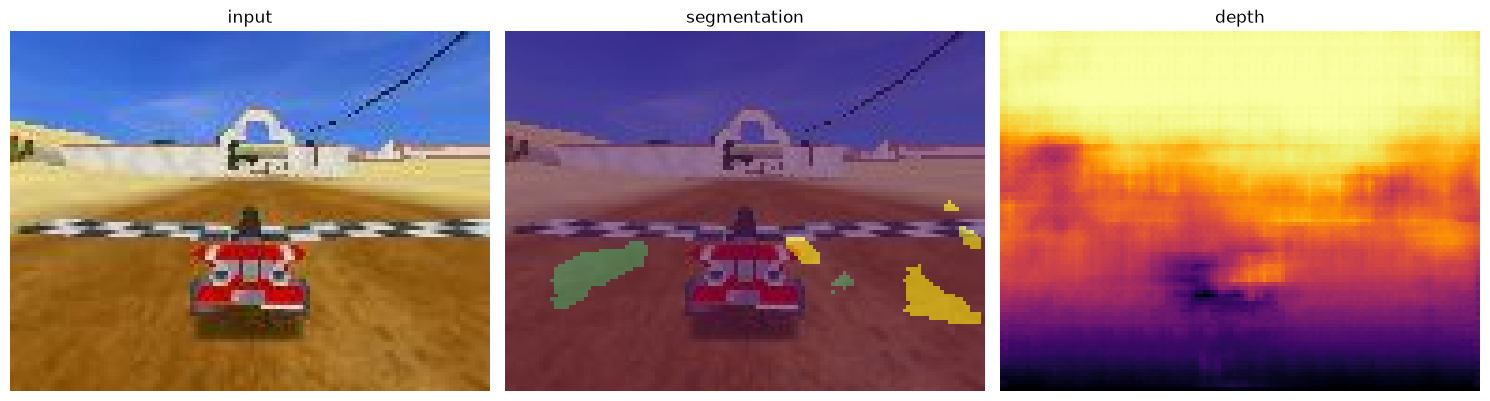

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(image_np)
axes[0].set_title("input")
axes[0].axis("off")

axes[1].imshow(image_np)
axes[1].imshow(pred.detach().numpy(), cmap="viridis", alpha=0.5)
axes[1].set_title("segmentation")
axes[1].axis("off")

axes[2].imshow(depth.detach().numpy(), cmap="inferno")
axes[2].set_title("depth")
axes[2].axis("off")

plt.tight_layout()